Carregando o arquivo e retirando informações descritivas e estatisticas

In [5]:
import pandas as pd

planilha_projeto = 'credit_risk_dataset.csv'

df = pd.read_csv(planilha_projeto)

# Exibir o tamanho total da base (linhas e colunas)
print("Tamanho do DataFrame (linhas, colunas):")
print(df.shape)

# Exibir os tipos de dados de cada variável
print("\nTipos de dados de cada variável:")
print(df.info())

# Exibir o sumário estatístico descritivo
print("\nSumário estatístico descritivo:")
display(df.describe())

Tamanho do DataFrame (linhas, colunas):
(32581, 12)

Tipos de dados de cada variável:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes:

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### 1. Histograma da Distribuição de Idades

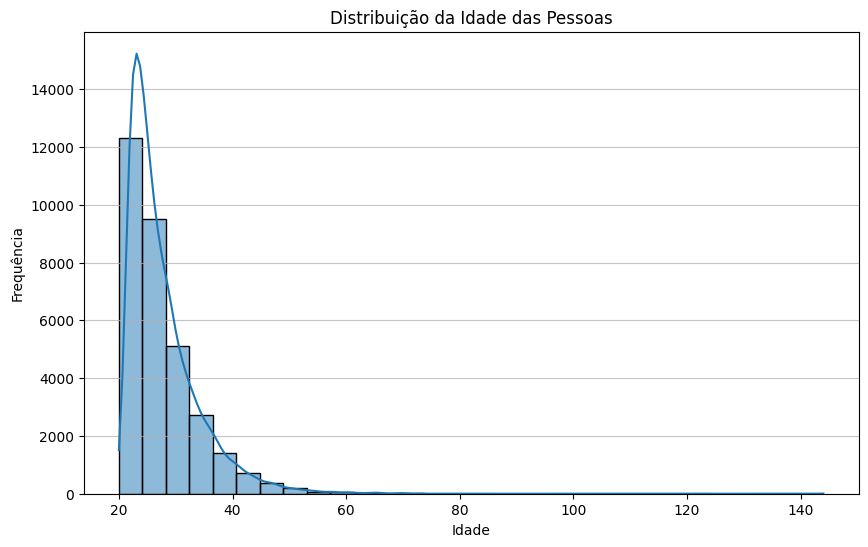

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['person_age'], bins=30, kde=True)
plt.title('Distribuição da Idade das Pessoas')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 2. Gráfico de Barras do Desbalanceamento da Variável Alvo (`loan_status`)

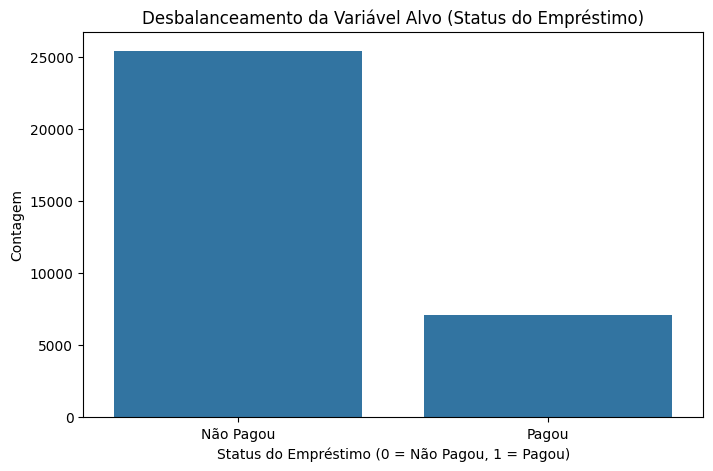

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['loan_status'])
plt.title('Desbalanceamento da Variável Alvo (Status do Empréstimo)')
plt.xlabel('Status do Empréstimo (0 = Não Pagou, 1 = Pagou)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não Pagou', 'Pagou'])
plt.show()

### 3. Mapa de Calor da Correlação de Pearson

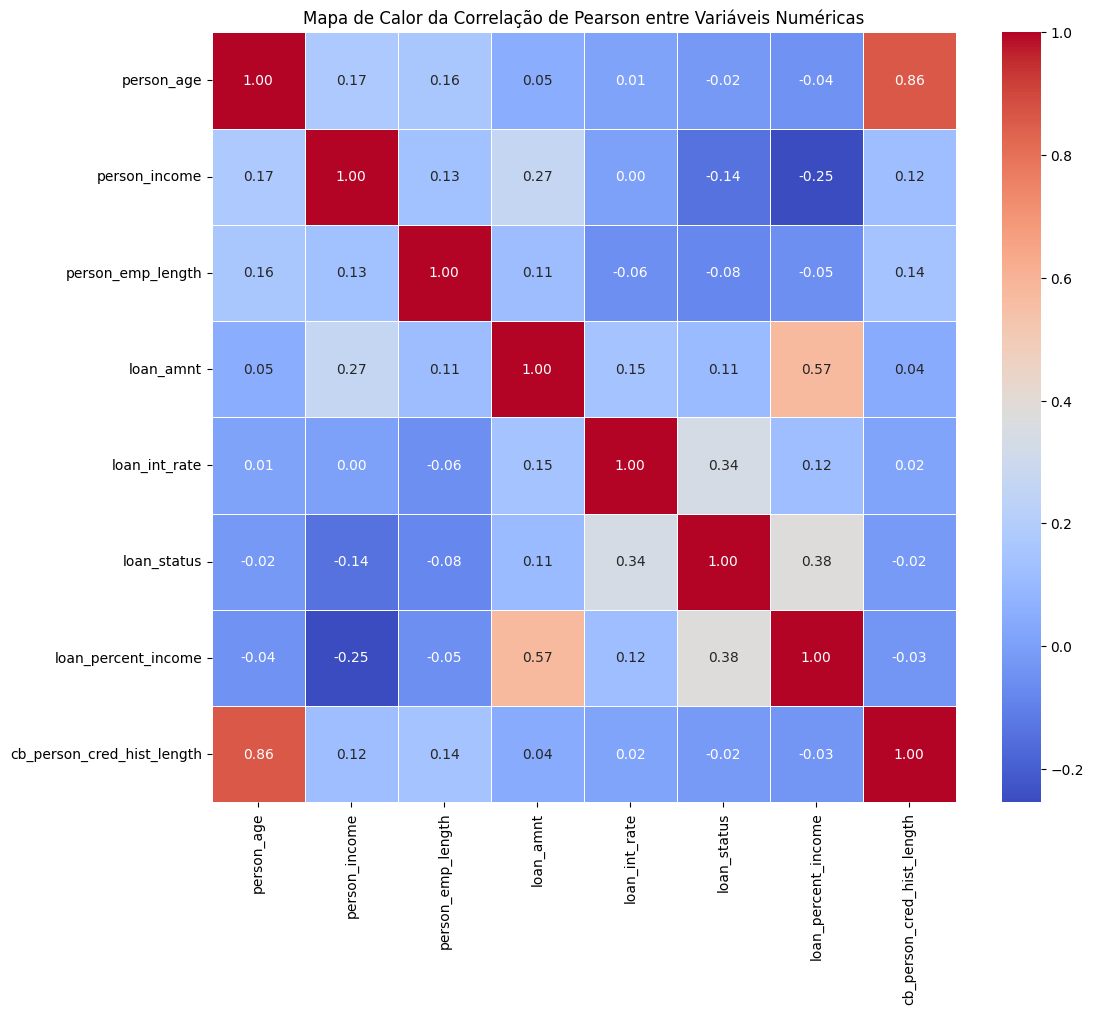

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

Visão Geral dos Dados: O conjunto de dados contém 32.581 entradas e 12 variáveis. As variáveis numéricas incluem idade, renda, valor do empréstimo, taxa de juros e histórico de crédito. As variáveis categóricas incluem posse de casa, intenção do empréstimo, grau do empréstimo e se a pessoa deu um "default" no histórico.

Valores Ausentes: Duas colunas numéricas, person_emp_length (duração do emprego) e loan_int_rate (taxa de juros do empréstimo), possuem valores ausentes. person_emp_length tem 31.686 valores não nulos (cerca de 2.7% ausentes), enquanto loan_int_rate tem 29.465 valores não nulos (cerca de 9.6% ausentes). A estratégia de preparação precisará abordar esses valores, seja por imputação (média, mediana, moda) ou remoção das linhas, dependendo da proporção e do impacto na análise.

Distribuição de Idade (person_age): O histograma de idade revela que a maioria das pessoas no dataset está na faixa etária mais jovem, com uma concentração em torno dos 20 a 30 anos. Isso é importante para entender o perfil do cliente e pode influenciar a forma como o risco de crédito é avaliado.

Desbalanceamento da Variável Alvo (loan_status): O gráfico de barras para loan_status (indicando se o empréstimo foi pago ou não) mostra um desequilíbrio significativo. Há muito mais casos de empréstimos pagos (0) do que não pagos (1). Esse desbalanceamento é crítico para a modelagem preditiva e exigirá técnicas como sobreamostragem (SMOTE), subamostragem ou ajuste de pesos na fase de treinamento do modelo para evitar que o modelo seja viesado para a classe majoritária.

Correlações: O mapa de calor da correlação de Pearson entre as variáveis numéricas indica as relações lineares entre elas. As variáveis com maior correlação com a loan_status (variável alvo) serão particularmente relevantes para a seleção de características. Observar as correlações entre as características também pode ajudar a identificar multicolinearidade, que pode afetar alguns modelos.

Estratégia de Preparação:

Tratamento de Valores Ausentes: Será necessário decidir a melhor abordagem para person_emp_length e loan_int_rate. A imputação com a mediana ou a média pode ser uma opção, ou a remoção de linhas se os valores ausentes não forem muitos e a remoção não impactar significativamente o tamanho do dataset.
Codificação de Variáveis Categóricas: As variáveis person_home_ownership, loan_intent, loan_grade e cb_person_default_on_file precisarão ser codificadas em formato numérico para serem utilizadas em modelos de machine learning. One-Hot Encoding ou Label Encoding são opções a serem consideradas.
Balanceamento da Variável Alvo: Para lidar com o desbalanceamento em loan_status, técnicas como SMOTE ou ajuste de pesos das classes serão aplicadas para garantir que o modelo não ignore a classe minoritária (empréstimos não pagos).
Análise de Outliers: Embora não explicitamente solicitado, a distribuição das idades e outras variáveis numéricas pode conter outliers que podem precisar de tratamento, como capping ou flooring, para melhorar o desempenho do modelo.
Normalização/Padronização: As variáveis numéricas podem ter escalas muito diferentes, o que pode afetar o desempenho de alguns algoritmos. Normalização (Min-Max Scaling) ou padronização (Standard Scaling) pode ser aplicada se necessário.

### 4. Tratamento de Valores Duplicados

In [14]:
# Identificar e contar linhas duplicadas
duplicate_rows = df.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {duplicate_rows}")

Número de linhas duplicadas encontradas: 165


#### Justificativa para a remoção de duplicatas
As linhas duplicadas geram redundância nos dados e podem enviesar análises e modelos. A remoção garante que cada observação seja única, resultando em um dataset mais limpo e confiável.

In [15]:
# Remover linhas duplicadas
df_no_duplicates = df.drop_duplicates().copy() # Usando .copy() para evitar SettingWithCopyWarning
print("Tamanho do DataFrame após remover duplicatas (linhas, colunas):")
print(df_no_duplicates.shape)

Tamanho do DataFrame após remover duplicatas (linhas, colunas):
(32416, 12)


### 5. Tratamento de Valores Ausentes

In [16]:
# Identificar valores ausentes por coluna
missing_values = df_no_duplicates.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Valores ausentes por coluna antes da imputação:")
print(missing_values)

Valores ausentes por coluna antes da imputação:
person_emp_length     887
loan_int_rate        3095
dtype: int64


#### Justificativa para a escolha da técnica de imputação (Mediana)

Para as colunas `person_emp_length` (duração do emprego) e `loan_int_rate` (taxa de juros do empréstimo), foi escolhida a **mediana** para imputar os valores ausentes.

*   **`person_emp_length`**: Dados como duração de emprego frequentemente apresentam distribuições assimétricas, com valores concentrados em faixas menores e alguns outliers (pessoas com empregos muito longos). A mediana é robusta a esses outliers e à assimetria, representando melhor o valor central típico sem ser distorcida por valores extremos, ao contrário da média.

*   **`loan_int_rate`**: Taxas de juros também podem ter distribuições não-normais e, por vezes, apresentar outliers (taxas muito altas ou muito baixas para casos específicos). A mediana minimiza o impacto desses valores extremos, fornecendo uma estimativa mais representativa para a taxa de juros comum.

In [17]:
# Imputar valores ausentes com a mediana
for column in missing_values.index:
    median_value = df_no_duplicates[column].median()
    df_no_duplicates[column].fillna(median_value, inplace=True)
    print(f"Coluna '{column}': Valores ausentes imputados com a mediana ({median_value}).")

Coluna 'person_emp_length': Valores ausentes imputados com a mediana (4.0).
Coluna 'loan_int_rate': Valores ausentes imputados com a mediana (10.99).


/tmp/ipykernel_599/2941742747.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_no_duplicates[column].fillna(median_value, inplace=True)


In [18]:
# Verificar novamente a quantidade de valores ausentes após a imputação
print("Valores ausentes por coluna após a imputação:")
print(df_no_duplicates.isnull().sum())

Valores ausentes por coluna após a imputação:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
